### **ATTRIBUTES OF AN AI AGENT**

- Autonomy (it can be controlled using permission scope, human-in-the-loop, override controls, guardrails, etc)
- Goal Oriented
- Planning and Reasoning
- Adaptability

### **Langchain VS Langgraph**

- Workflow vs agentic system
- Loops and conditional jumps
- State management
- Event driven execution
- Fault tolerance
- HITL
- Nested Workflows (subgraphs)
- Observability (langsmith)

### **CORE CONCEPTS IN LANGGRAPH**
#### **LLM workflows**: step by step process by which complex tasks can be achieved


##### Common Workflows
- Prompt Chaining
- Routing
- Parallelisation
- Orchestrator worker (subtyoe of parallel, in this we dont know before-hand what exact tasks will be performed)
- Evaluator optimizer

#### **Graphs, nodes and edges**: these are components in langgraph

#### **Agent-State**: used to keep track of required evolving data, uses set of key-value pair for creating state
- Accessible to al nodes
- Mutable by all available nodes individually

#### **Reducers**: it defined how the shared state will be updated by the nodes based on what is required for the application

### **Starting the code part**
#### **Sequential workflows**

In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [6]:
class BMIstate(TypedDict):
    height_m: float
    weight_kg: float
    bmi:float

In [7]:
def calculate_bmi(state: BMIstate) -> BMIstate:
    state['bmi'] = round(state['weight_kg']/(state['height_m']**2), 2)

    return state

In [16]:
graph = StateGraph(BMIstate)

In [17]:
graph.add_node("calculate_bmi", calculate_bmi)

In [18]:
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", END)

In [19]:
workflow = graph.compile()

In [20]:
workflow.invoke({"weight_kg": 63, "height_m":1.75})

{'height_m': 1.75, 'weight_kg': 63, 'bmi': 20.57}

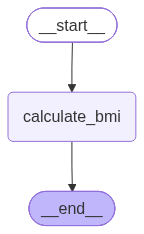

In [21]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

#### **Parallel workflows**

In [62]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [63]:
class batsPerson(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    bp: float
    summary: str

In [64]:
def calculate_sr(state: batsPerson):
    
    sr = (state['runs']/state['balls'])*100

    return {"sr": sr}

In [65]:
def calculate_bpb(state: batsPerson):

    bpb = (state["fours"]+state["sixes"])/state["balls"]

    return {"bpb": bpb}

In [66]:
def calculate_bp(state: batsPerson):

    bp = ((state["fours"]*4)+(state["sixes"]*6)/state["runs"])*100

    return {"bp":bp}

In [67]:
def summary(state: batsPerson):

    state["summary"] = f'''strike rate: {state['sr']}
balls per boundary: {state["bpb"]}
boundary percentage: {state["bp"]}'''

    return state

In [68]:
graph = StateGraph(batsPerson)

In [69]:
graph.add_node("calculate_sr", calculate_sr)
graph.add_node("calculate_bpb", calculate_bpb)
graph.add_node("calculate_bp", calculate_bp)
graph.add_node("summary", summary)

In [70]:
graph.add_edge(START, "calculate_sr")
graph.add_edge(START, "calculate_bpb")
graph.add_edge(START, "calculate_bp")

In [71]:
graph.add_edge("calculate_sr", "summary")
graph.add_edge("calculate_bpb", "summary")
graph.add_edge("calculate_bp", "summary")

In [72]:
graph.add_edge("summary", END)

In [73]:
workflow = graph.compile()

In [74]:
initial_state = {
    "runs": 264,
    "balls": 164,
    "fours": 21,
    "sixes": 15,
}

In [75]:
workflow.invoke(initial_state)

{'runs': 264,
 'balls': 164,
 'fours': 21,
 'sixes': 15,
 'sr': 160.97560975609758,
 'bpb': 0.21951219512195122,
 'bp': 8434.09090909091,
 'summary': 'strike rate: 160.97560975609758\nballs per boundary: 0.21951219512195122\nboundary percentage: 8434.09090909091'}

In [76]:
def model_setup():
    from dotenv import load_dotenv
    load_dotenv()

    from langchain_google_genai import ChatGoogleGenerativeAI
    model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

    return model

- **Reducers usage**: suppose we want to constraint how an variable in agentstate would be updated by differnt nodes, for example we want to merge the output form three different nodes into one single list then we can do it using reducers

In [78]:
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated
import operator

- in the list created below when the different nodes will return a list then all the list would be merged into one singular list and stored in the state variable of `list_variable`, eg: three nodes returned `[8], [5], [7]` then the `list_variable` would become `[8, 5, 7]`

In [79]:
class state(BaseModel):
    list_variable: Annotated[list[int], operator.add]